In [1]:
from graph_tool.all import *
import numpy as np

# Susceptible: 0
# Infectado: 1
# Debilitado: 2
# Recuperado: 3

In [2]:
def swir(n, z, rho0, kappa, mu, eta):
    p = z/n
    ss = 1 - mu - kappa
    ww = 1 - eta
    
    # inicialización del grafo erdos renyi
    g = random_graph(n, lambda: np.random.poisson((n-1) * p), directed=False, model="erdos")

    # declarar una propiedad llamada "estado" que va a guardar el estado de cada nodo
    estado = g.new_vertex_property("short")

    # Asignar a todos los nodos el estado susceptible
    estado.get_array()[:] = 0

    # Generar rho0*n índices aleatorios
    infected_index = np.random.choice(np.arange(0, n), size=int(n*rho0), replace=False)

    # Actualizar el estado de rho0*n nodos al estado infectado
    estado.get_array()[infected_index] = 1

    # Iterador que contiene los nodos infectados
    I = (g.vertex(i) for i in infected_index)
    
    def reaction(vertex):
        """
        Función que realiza un paso de tiempo para un nodo infectado:
        vertex es un nodo en estado infectado.
        """
        # inicia una lista que guarda los nodos que serán infectados
        new_infected = []
        # actualiza el estado del nodo actual infectado a recuperado
        estado[vertex] = 3
        # obtiene los vecinos del nodo infectado
        vecinos = vertex.out_neighbors()
        # obtiene un iterador de los nodos en estado susceptible
        S = (v for v in vecinos if estado[v]==0)
        # obtiene un iterador de los nodos en estado debilitado
        W = (v for v in vecinos if estado[v]==2)
        # itera sobre los susceptibles
        for s in S:
            # calcula el nuevo estado del nodo susceptible
            new_state = np.random.choice([0, 1, 2], size=1, p=[ss, kappa, mu])
            # asigna el nuevo estado del nodo susceptible
            estado[s] = new_state
            # revisa si el nuevo estado es infectado para añadirlo a la lista que guarda la lista de los infectados
            if new_state == 1:
                new_infected.append(s)
        # itera sobre los debilitados
        for w in W:
            #calcula el nuevo estado del nodo debilitado
            new_state = np.random.choice([2, 1], size=1, p=[ww, eta])
            #asigna el nuevo estado del nodo debilitado
            estado[w] = new_state
            # revisa si el nuevo estado es infectado para añadirlo a la lista que guarda la lista de los infectados
            if new_state == 1:
                new_infected.append(s)
        # devuelve los vecinos que se infectaron
        return new_infected
    while I:
        # inicia una lista que guarda los nodos que serán infectados en el paso de tiempo n
        new_infected_n = []
        # itera sobre los nodos infectados
        for i in I:
            # hace que el nodo infectado reaccione con sus vecinos
            ni = reaction(i)
            # agrega los vecinos infectados a la lista de los nuevos infectados
            new_infected_n.append(ni)
        # actualiza la lista de los nuevos infectados para el paso de tiempo n+1
        I = [s for sublist in new_infected_n for s in sublist]
    return estado.get_array()

In [3]:
from pathos.multiprocessing import ProcessingPool as Pool
import tqdm

In [4]:
N = 10000
def worker_function(kappa, N):
    return swir(N, 8, 2e-3, kappa, kappa, 0.5)

kappa_range = (np.linspace(-1, 1, 40))**3
kappa_range = (kappa_range-kappa_range.min()) * (0.118 - 0.11) / 2 + 0.11
kappa_range = np.linspace(0.1, 0.4999, 30)

#results = []
#for kappa in tqdm.tqdm(kappa_range):
#    results.append(worker_function(kappa))

with Pool(4) as pool:
    results = list(tqdm.tqdm(pool.imap(worker_function, kappa_range, (N for n in range(N))), total=kappa_range.size))

100%|██████████| 30/30 [00:10<00:00,  3.67it/s]


In [5]:
ms = []
for r in results:
    m = np.count_nonzero(r == 3)/N
    ms.append(m)

In [6]:
import matplotlib.pyplot as plt

In [7]:
results[0][:100]

PropertyArray([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
               0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
               0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
               0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
               0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2],
              dtype=int16)

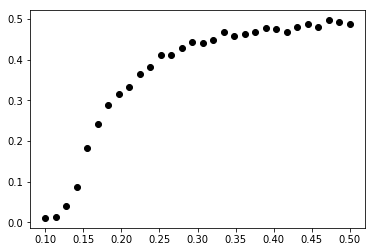

In [8]:
plt.plot(kappa_range, ms, 'ko')

In [32]:
from time import time

Ns = [int(n) for n in np.geomspace(100, 100000, 7)]
times = []
for n in Ns:
    t0 = time()
    est = swir(n, 8, 0.1, 0.2, 0.1, 0.1)
    t = time()-t0
    print(t)
    times.append(t)

0.020766258239746094
0.07914113998413086
0.26991915702819824
0.8224437236785889
2.5991108417510986
8.290196895599365
26.28043270111084


In [34]:
z = np.polyfit(np.log(Ns), np.log(times), 1)
p = np.poly1d(z)
print(np.exp(p(np.log(40e6)))/60/24)

8.762609772619713


In [2]:
# número de nodos
n = 10
# grado medio
z = 3
# probabilidad de que entre dos nodos escogidos aleatoriamente exista una arista
p = z/n
# densidad inicial de nodos infectados
rho0 = 0.5
# probabilidad de que un nodo susceptible se infecte
kappa= 0.2
# probabilidad de que un nodo susceptible se debilite
mu = 0.1
#probabilidad de que un nodo debilitado se infecte
eta = 0.1
# probabilidad de que un nodo susceptible no cambie de estado al interactuar con un nodo infectado
ss = 1 - mu - kappa
# probabilidad de que un nodo debilitado no cambie de estado al interactuar con un nodo infectado
ww = 1 - eta

# inicialización del grafo erdos renyi
g = random_graph(n, lambda: np.random.poisson((n-1) * p), directed=False, model="erdos")

# declarar una propiedad llamada "estado" que va a guardar el estado de cada nodo
estado = g.new_vertex_property("short")

# Asignar a todos los nodos el estado susceptible
estado.get_array()[:] = 0

# Generar rho0*n índices aleatorios
infected_index = np.random.choice(np.arange(0, n), size=int(n*rho0), replace=False)

# Actualizar el estado de rho0*n nodos al estado infectado
estado.get_array()[infected_index] = 1

# Iterador que contiene los nodos infectados
I = (g.vertex(i) for i in infected_index)

In [25]:
# Mejorar con las ideas de la documentación de graph_tool:
# Fast iteration over vertices and edges

def reaction(vertex):
    """
    Función que realiza un paso de tiempo para un nodo infectado:
    vertex es un nodo en estado infectado.
    """
    # inicia una lista que guarda los nodos que serán infectados
    new_infected = []
    # actualiza el estado del nodo actual infectado a recuperado
    estado[vertex] = 3
    # obtiene los vecinos del nodo infectado
    vecinos = vertex.out_neighbors()
    # obtiene un iterador de los nodos en estado susceptible
    S = (v for v in vecinos if estado[v]==0)
    # obtiene un iterador de los nodos en estado debilitado
    W = (v for v in vecinos if estado[v]==2)
    # itera sobre los susceptibles
    for s in S:
        # calcula el nuevo estado del nodo susceptible
        new_state = np.random.choice([0, 1, 2], size=1, p=[ss, kappa, mu])
        # asigna el nuevo estado del nodo susceptible
        estado[s] = new_state
        # revisa si el nuevo estado es infectado para añadirlo a la lista que guarda la lista de los infectados
        if new_state == 1:
            new_infected.append(s)
    # itera sobre los debilitados
    for w in W:
        #calcula el nuevo estado del nodo debilitado
        new_state = np.random.choice([2, 1], size=1, p=[ww, eta])
        #asigna el nuevo estado del nodo debilitado
        estado[w] = new_state
        # revisa si el nuevo estado es infectado para añadirlo a la lista que guarda la lista de los infectados
        if new_state == 1:
            new_infected.append(s)
    # devuelve los vecinos que se infectaron
    return new_infected

In [26]:
# revisa si hay nodos infectados
while I:
    # inicia una lista que guarda los nodos que serán infectados en el paso de tiempo n
    new_infected_n = []
    # itera sobre los nodos infectados
    for i in I:
        # hace que el nodo infectado reaccione con sus vecinos
        ni = reaction(i)
        # agrega los vecinos infectados a la lista de los nuevos infectados
        new_infected_n.append(ni)
    # actualiza la lista de los nuevos infectados para el paso de tiempo n+1
    I = [s for sublist in new_infected_n for s in sublist]

[1 0 1 1 1 0 1 0 0 0]
[1 0 1 3 1 0 1 1 0 0]
[<Vertex object with index '7' at 0x7f7a1b01bd50>]
----------------------
[1 0 1 3 1 0 1 1 0 0]
[1 0 1 3 1 0 3 1 1 0]
[<Vertex object with index '8' at 0x7f7a1b01b690>]
----------------------
[1 0 1 3 1 0 3 1 1 0]
[1 0 1 3 3 1 3 1 1 0]
[<Vertex object with index '5' at 0x7f7a1b01b5d0>]
----------------------
[1 0 1 3 3 1 3 1 1 0]
[3 0 1 3 3 1 3 1 1 0]
[]
----------------------
[3 0 1 3 3 1 3 1 1 0]
[3 0 3 3 3 1 3 1 1 0]
[]
----------------------
PASO DE TIEMPO
[3 0 3 3 3 1 3 1 1 0]
[3 1 3 3 3 1 3 3 1 0]
[<Vertex object with index '1' at 0x7f7a1b01b1b0>]
----------------------
[3 1 3 3 3 1 3 3 1 0]
[3 1 3 3 3 1 3 3 3 0]
[]
----------------------
[3 1 3 3 3 1 3 3 3 0]
[3 1 3 3 3 3 3 3 3 0]
[]
----------------------
PASO DE TIEMPO
[3 1 3 3 3 3 3 3 3 0]
[3 3 3 3 3 3 3 3 3 0]
[]
----------------------
PASO DE TIEMPO
